In [1]:
# моделирование идеального газа,
# состоящего из одной частицы

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit

# подключение метода norm из библиотеки stat
from scipy.stats import norm

In [ ]:
# Ячейка № 2

# задание функции, возвращающей:
# мгновенные значения скорости частицы идеального газа;
# энергии идеального газа;
# отношения числа принятых изменений значений
# энергии идеального газа к силу шагов
# метода Монте-Карло
def Ideal_Gas_One_Particle(Vel, T, dV_max, N_Trial):
    # Vel - начальная скорость частицы
    # T - температура газа
    # dV_max - значение, определяющее диапазон
    #          изменения скорости ([-dV_max /2, dV_max /2])

    # инициализация массива, используемого
    # для хранения мгновенных значений
    # энергии идеального газа
    E_System = np.zeros(N_Trial)

    # инициализация массива, используемого
    # для хранения мгновенных значений
    # скорости частицы
    V = np.zeros(N_Trial)

    # вычисление начальной энергии
    # идеального газа
    E = Vel**2 / 2

    # инициализация счетчика числа принятых
    # изменений скорости частицы и
    # энергии идеального газа
    N_Accept = 0

    # задание функции, реализующей алгоритма Метрополиса
    for i in range(N_Trial):
        # задание случайной величины изменения скорости частицы
        dV = random.uniform(-dV_max / 2, dV_max / 2)
        # вычисление измененного значения скорости
        V_Trial = Vel + dV
        # вычисление измененного значения энергии
        dE = (V_Trial**2 - Vel**2) / 2
        if dE > 0:
            # сравнение вероятности перехода
            # в новое состояние со случайным числом,
            #  генерируемым в соответствие
            # с равномерным законом распределения на интервале [0,1]
            if np.exp(-dE / T) >= random.uniform(0, 1):
                # изменения принимаются
                Vel = V_Trial
                N_Accept = N_Accept + 1
                E = E + dE
        else:
            # dE < 0, поэтому изменения принимаются
            Vel = V_Trial
            N_Accept = N_Accept + 1
            E = E + dE
        # сохранение мгновенного значения
        # энергии идеального газа
        E_System[i] = E
        # сохранение мгновенного значения
        # скорости частицы
        V[i] = Vel
    return V, E_System, N_Accept / N_Trial

In [ ]:
# Ячейка № 3

# инициализация генератора случайных чисел
random.seed()

# задание скорости частицы
Vel = 0

# задание температуры идеального газа
T = 0.5

# задание значения значение,
# определяющего диапазон пробного
# изменения скорости ([-dV_max /2, dV_max /2])
dV_max = 4

# задание числа шагов метода Монте-Карло
N_Trial = 10**5

# вычисление мгновенных значений:
# скорости частицы идеального газа (Vel);
# энергии идеального газа (E_System);
# отношения числа принятых изменений значений
# энергии идеального газа к числу шагов
# метода Монет-Карло
[V, E_System, Accept] = Ideal_Gas_One_Particle(Vel, T, dV_max, N_Trial)

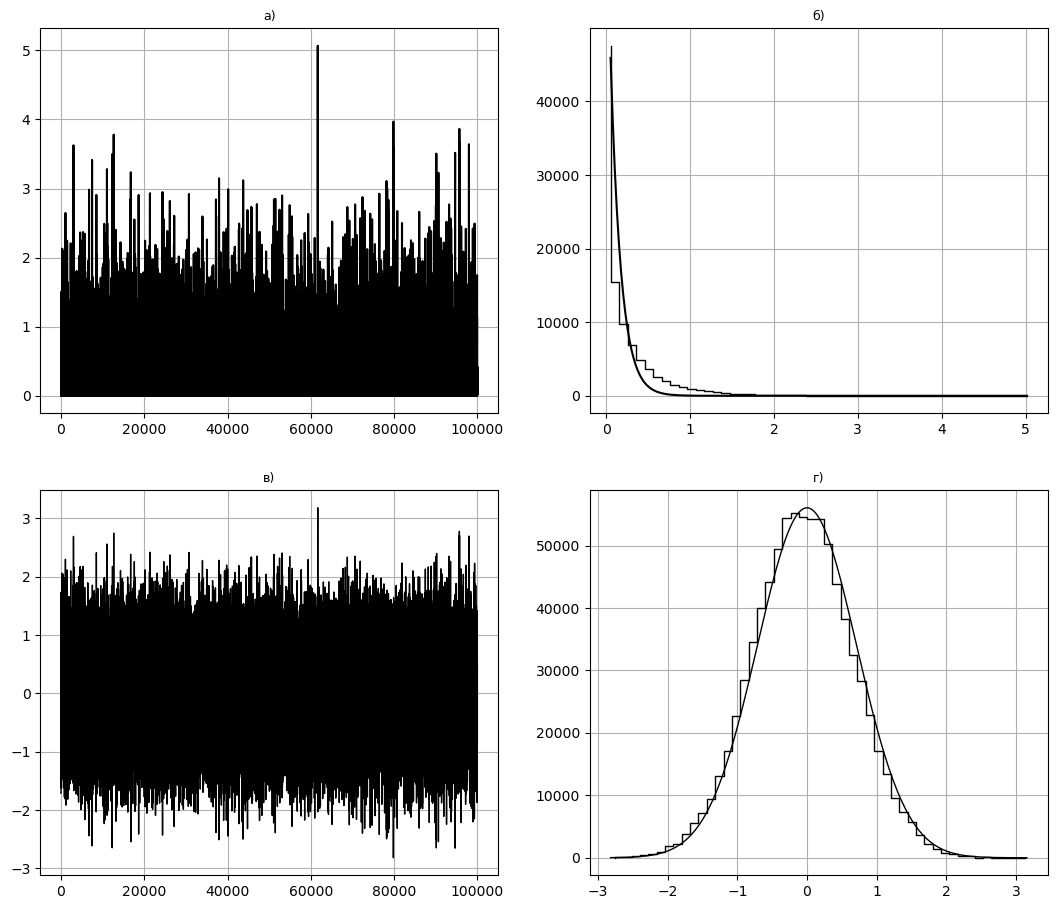

Средняя энергия идеального газа: 0.2531930457476326 

Относительное число принятых измений энергии: 0.51532


In [ ]:
# Ячейка № 4

# визуализация показателей состояния
# моделируемого идеального газа

# вычисление последовательностей,
# составленных из мгновенных значений
#  энергии идеального газа и скорости частицы
fig = plt.figure(figsize=(13, 11))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 1)
plt.plot(E_System, color="black")
plt.grid(True)
ax.set_title("а)", fontsize=9)

# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных значений энергии демона,
# и аппроксимации ее эмпирической плотности распределения
ax = plt.subplot(2, 2, 2)

# вычисление координат интервалов гистограммы
N_bin = 49
xbins = np.arange(
    np.min(E_System), np.max(E_System), (max(E_System) - min(E_System)) / N_bin
)

# вычисление эмпирической
# плотности распределения
# мгновенных значений энергии
# идеального газа
H = np.histogram(E_System, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# мгновенной  энергии демона
# функцией вида a * sqrt(-b * x)
Coeff = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, H[0], bounds=(0, [N_Trial, 8]))
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# аппроксимации функцией вида a * sqrt(-b * x)
plt.step(x, H[0], "-k", lw=1)
plt.plot(x2, y, "-k")
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# энергии демона
ax = plt.subplot(2, 2, 3)
plt.plot(V, "-k", lw=1)
plt.grid(True)
ax.set_title("в)", fontsize=9)

# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных скорости частицы,
# и плотности нормального закона распределения,
# математическое ожидание и дисперсия которого
# оценки соответствующих параметров,
# вычисленные на основе значений
# анализируемой последовательности
ax = plt.subplot(2, 2, 4)

# вычисление координат узлов сетки,
# используемых для вычисления значений
# теоретической плотности распределения
N_bin = 200
xbins = np.arange(np.min(V), np.max(V), (max(V) - min(V)) / N_bin)

# вычисление эмпирической
# плотности распределения
# мгновенных значений скорости частицы
H = np.histogram(V, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление значения плотности
# нормального распределения
# N(x,np.mean(V),np.std(V)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве V
dP_est = norm.pdf(xbins, np.mean(V), np.std(V))

# визуализация эмпирической плотности распределения
# и сответствующего нормального распределения
ax = plt.subplot(2, 2, 4)
plt.step(x, H[0] / (x[1] - x[0]), "-k", lw=1)
plt.plot(xbins, N_Trial * dP_est, "-k", lw=1)
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()

print("Средняя энергия идеального газа:", np.mean(E_System), "\n")
print("Относительное число принятых изменений энергии:", Accept)